In [3]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./MNRAS.mplstyle')

import os, glob

import h5py

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/var/folders/tt/vqgmd2fd2_x1slpsxdb6wlqh0000gr/T/ipykernel_29625/1117010014.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=2)


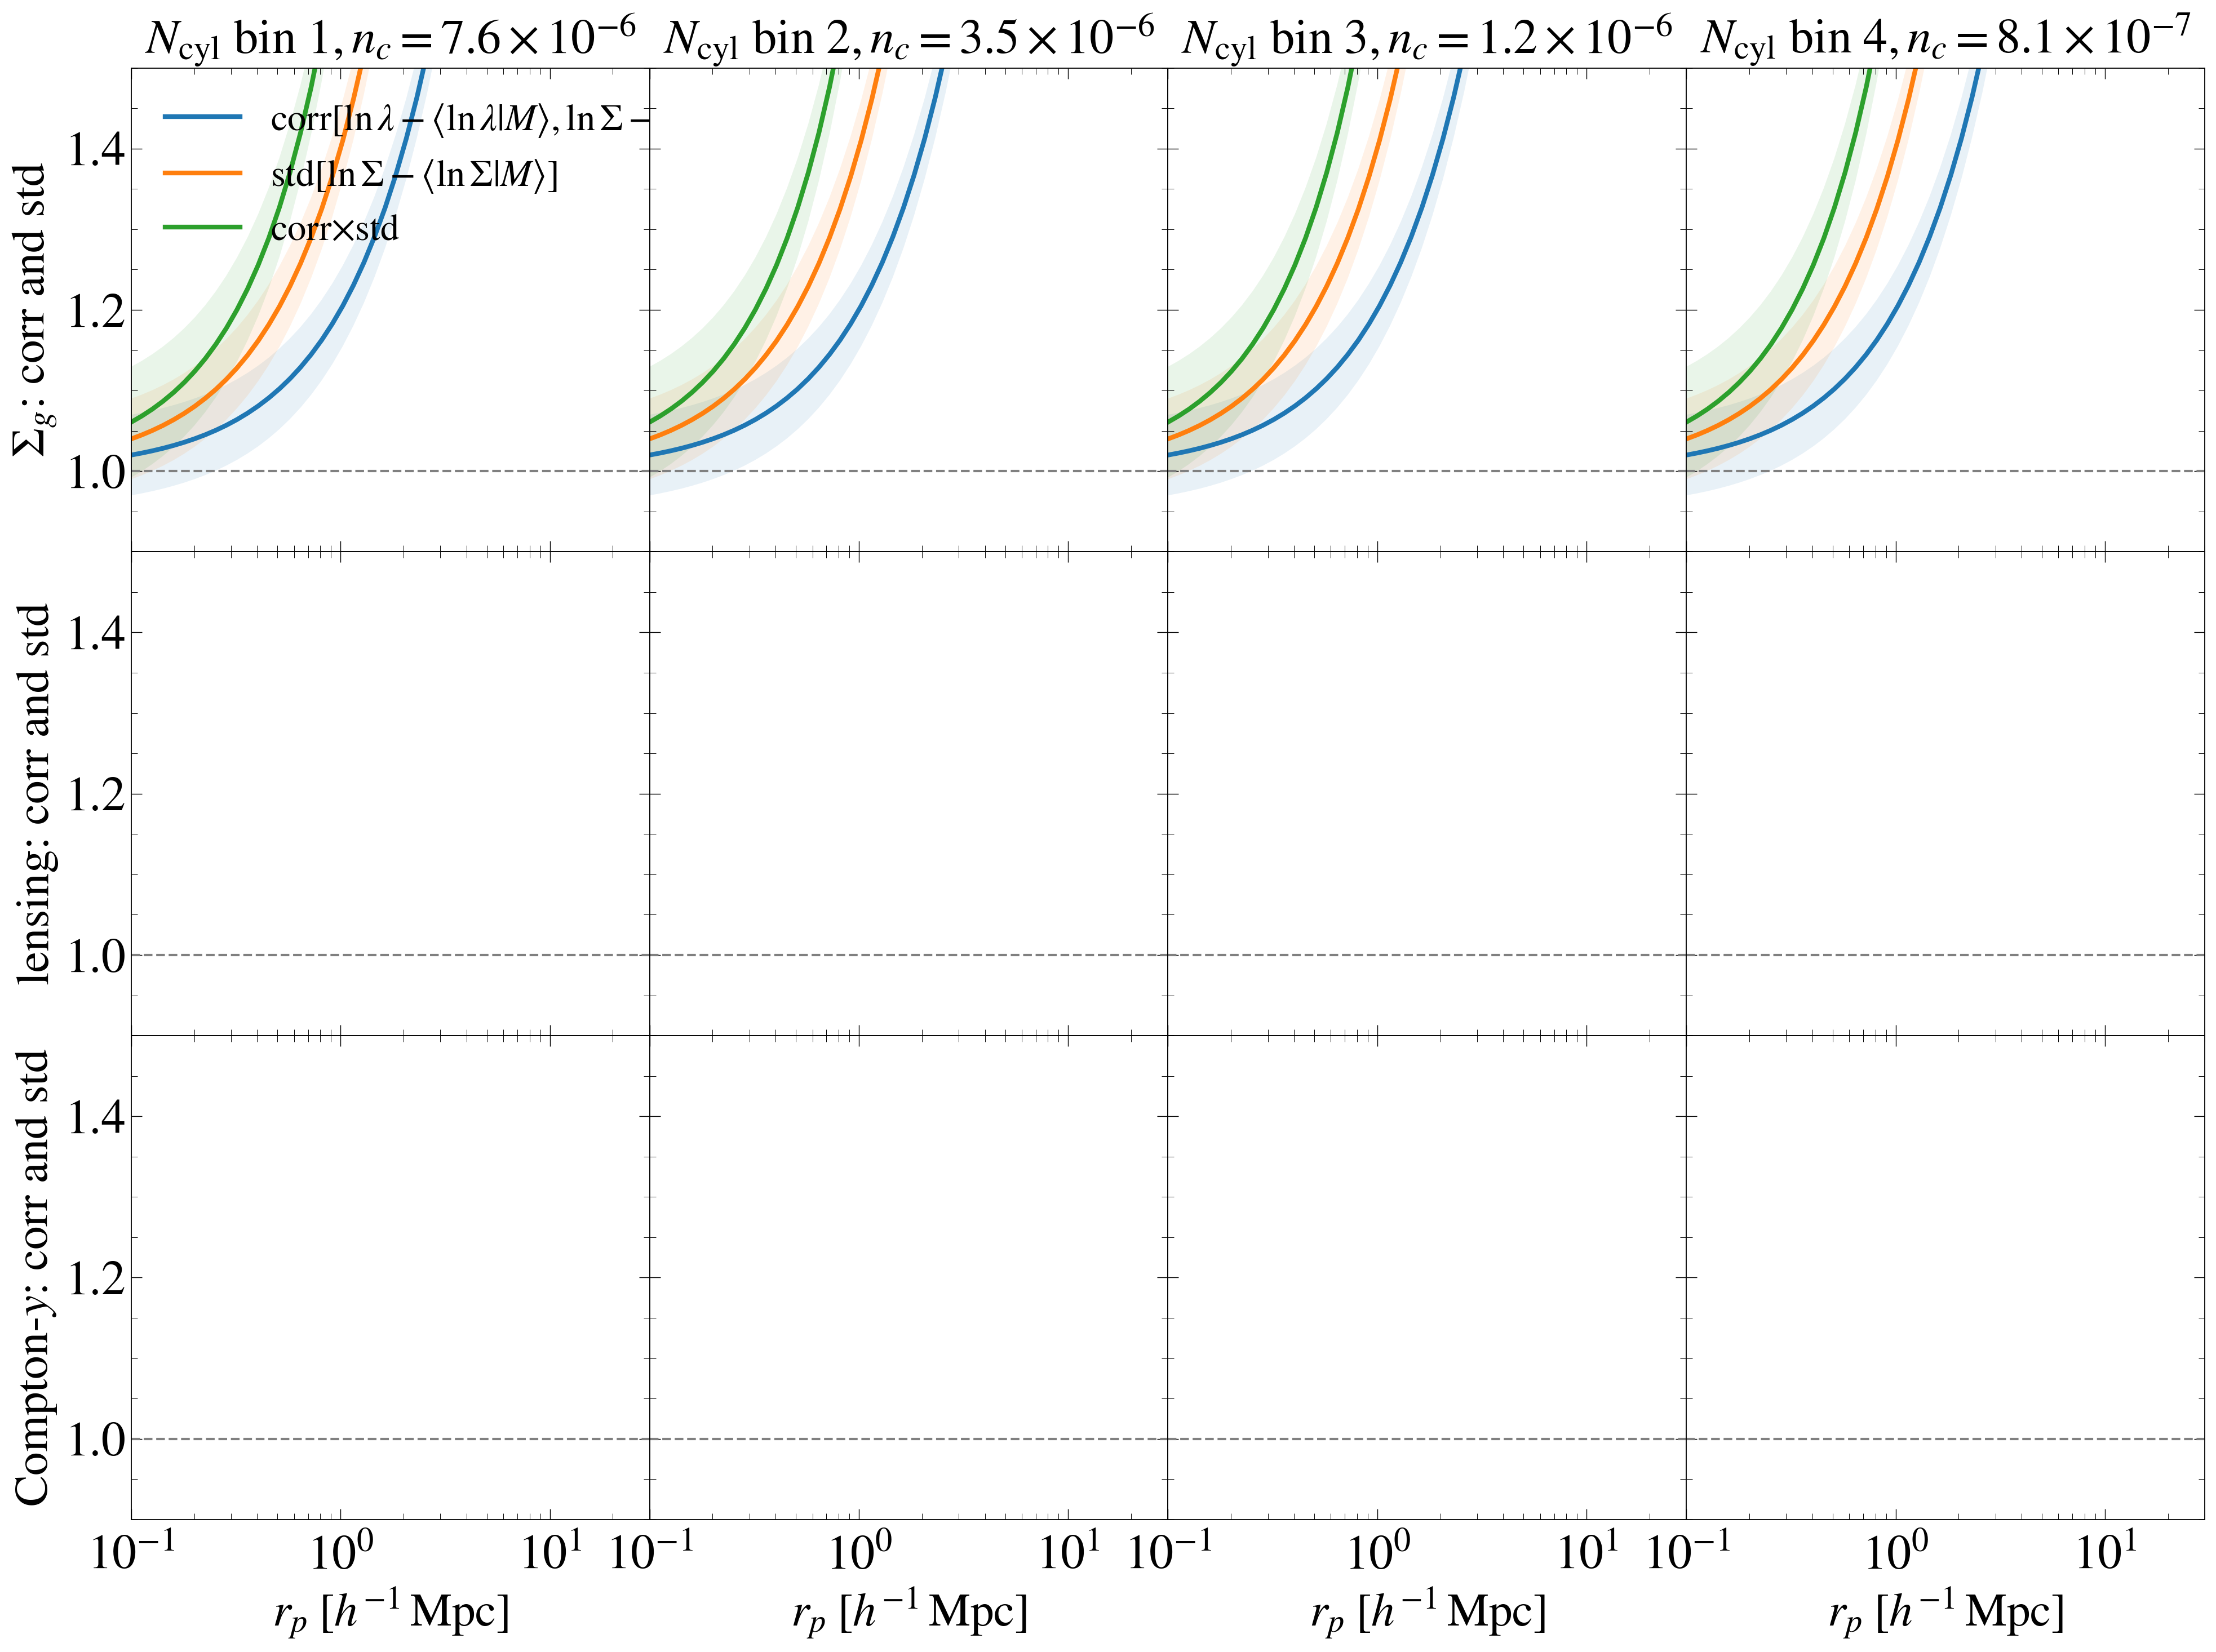

In [6]:
#### all panels use the same sample as richness_selection_*

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 15),
    sharex=True,
    gridspec_kw = {'wspace':0, 'hspace':0}
    , sharey='row',
)

col_titles = [
    r"$N_{\rm cyl} {\rm ~bin ~1}, n_c = 7.6\times10^{-6}$",  # Hard coded to show 10^{-6}
    r"$N_{\rm cyl} {\rm ~bin ~2}, n_c = 3.5\times10^{-6}$",
    r"$N_{\rm cyl} {\rm ~bin ~3}, n_c = 1.2\times10^{-6}$",
    r"$N_{\rm cyl} {\rm ~bin ~4}, n_c = 8.1\times10^{-7}$",
]

row_ylabels = [
    r"$\Sigma_g$: corr and std",
    r"lensing: corr and std",
    r"Compton-$y$: corr and std",
]

# obs_rows = ["DS", "Sigma", "cy", "ns_cy", "sigg_hd", "sigg_ld"]
gal_idx_fixed = 1 #  gal_num_dens for CIC richness "1.0e-02"
q_cyl_1 = 0
q_cyl_180 = 1
q_cyl_1h = 1 ## q_cyl=180 (richness); d_proj=1 (sigg/lensing/cy)

Vol_flamingo = (681.0)**3

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)# + rf"${(num_clus_used[col]/Vol_flamingo):.2e}$")

for row, ylabel in enumerate(row_ylabels):
    axes[row, 0].set_ylabel(ylabel)

for col in range(4):
    axes[2, col].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")

for row in range(3):
    for col in range(4):
        rich_bin = col

        ax = axes[row, col]
        if row == 0:  # galaxy distribution
            
            ### TODO: placeholder
            rp = np.geomspace(0.1, 30)
            corr = 0.2*rp+1 
            corr_err = 0.05
            scatt = 0.4*rp+1 
            scatt_err = 0.05

            corr_scatt_err = np.sqrt((corr_err/corr)**2 + (scatt_err/scatt)**2) # error propagation formula
            
            line = ax.plot(rp, corr, lw=3, label=r"corr$[\ln\lambda - \langle\ln\lambda|M  \rangle, \ln\Sigma_g - \langle \ln\Sigma_g|M \rangle]$")
            ax.fill_between(rp, corr-corr_err, corr+corr_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

            line = ax.plot(rp, scatt, lw=3, label=r"std$[\ln\Sigma - \langle \ln\Sigma|M \rangle]$")
            ax.fill_between(rp, scatt-scatt_err, scatt+scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
            
            line = ax.plot(rp, corr*scatt, lw=3, label=r"corr$\times$std")
            ax.fill_between(rp, corr*scatt+corr_scatt_err, corr*scatt-corr_scatt_err, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
            
            
        if row == 1:  # lensing
            pass ## TODO: same for lensing with d=300   ### Ncyl with q=180 only

        if row == 2:  # SZ
            pass ## TODO: same for y with d=300 (no noise)   ### Ncyl with q=180 only

        
        ax.axhline(1, c='gray', ls='--')
        ax.set_ylim(0.9, 1.5)
        ax.set_xlim(0.1, 30)
        ax.set_xscale('log')        
        if col==0:
            ax.legend(loc=2)
        ax.grid(False)
#plt.savefig('../plots/richness_selection_1halo.pdf')